# DSA 210 — Personalized Well-being Prediction from Sleep & Lifestyle Data
**Author:** Deniz Elbek | **Final Submission — EDA & Hypothesis Testing**

Full 44-night dataset (April 1 – May 14, 2026). 37 complete observations after excluding nights the Apple Watch was not worn.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

df = pd.read_csv('../data/sleep_data.csv', parse_dates=['date'])
df_ml = df[df[['duration_h','morning_feel','productivity']].notna().all(axis=1)].copy().reset_index(drop=True)
print(f'Full dataset: {len(df)} rows × {df.shape[1]} cols')
print(f'Complete observations: {len(df_ml)}')
df.head(3)

Full dataset: 44 rows × 33 cols
Complete observations: 37


,date,bedtime_hour,wake_hour,duration_h,deep_min,rem_min,core_min,awake_min,sleep_efficiency,apple_sleep_score,...,temp_min_c,humidity_pct,pressure_hpa,precip_mm,sunrise_hour,sunset_hour,daylight_h,bedtime_after_sunset,morning_feel,productivity
0,2026-04-01,3.52,15.73,12.21,31.7,243.4,437.0,20.6,97.2,89.0,...,9.3,76.2,1010.9,0.0,6.77,19.43,12.67,-15.91,10,0.0
1,2026-04-02,5.48,11.62,6.13,29.2,66.4,225.8,46.8,87.3,59.0,...,9.8,66.4,1010.3,5.6,6.73,19.45,12.72,-13.97,8,0.0
2,2026-04-03,4.02,10.42,6.39,30.7,89.5,251.9,11.6,97.0,84.0,...,9.9,65.5,1012.9,0.0,6.72,19.48,12.77,-15.46,10,0.0


## 2. Sleep Schedule Overview

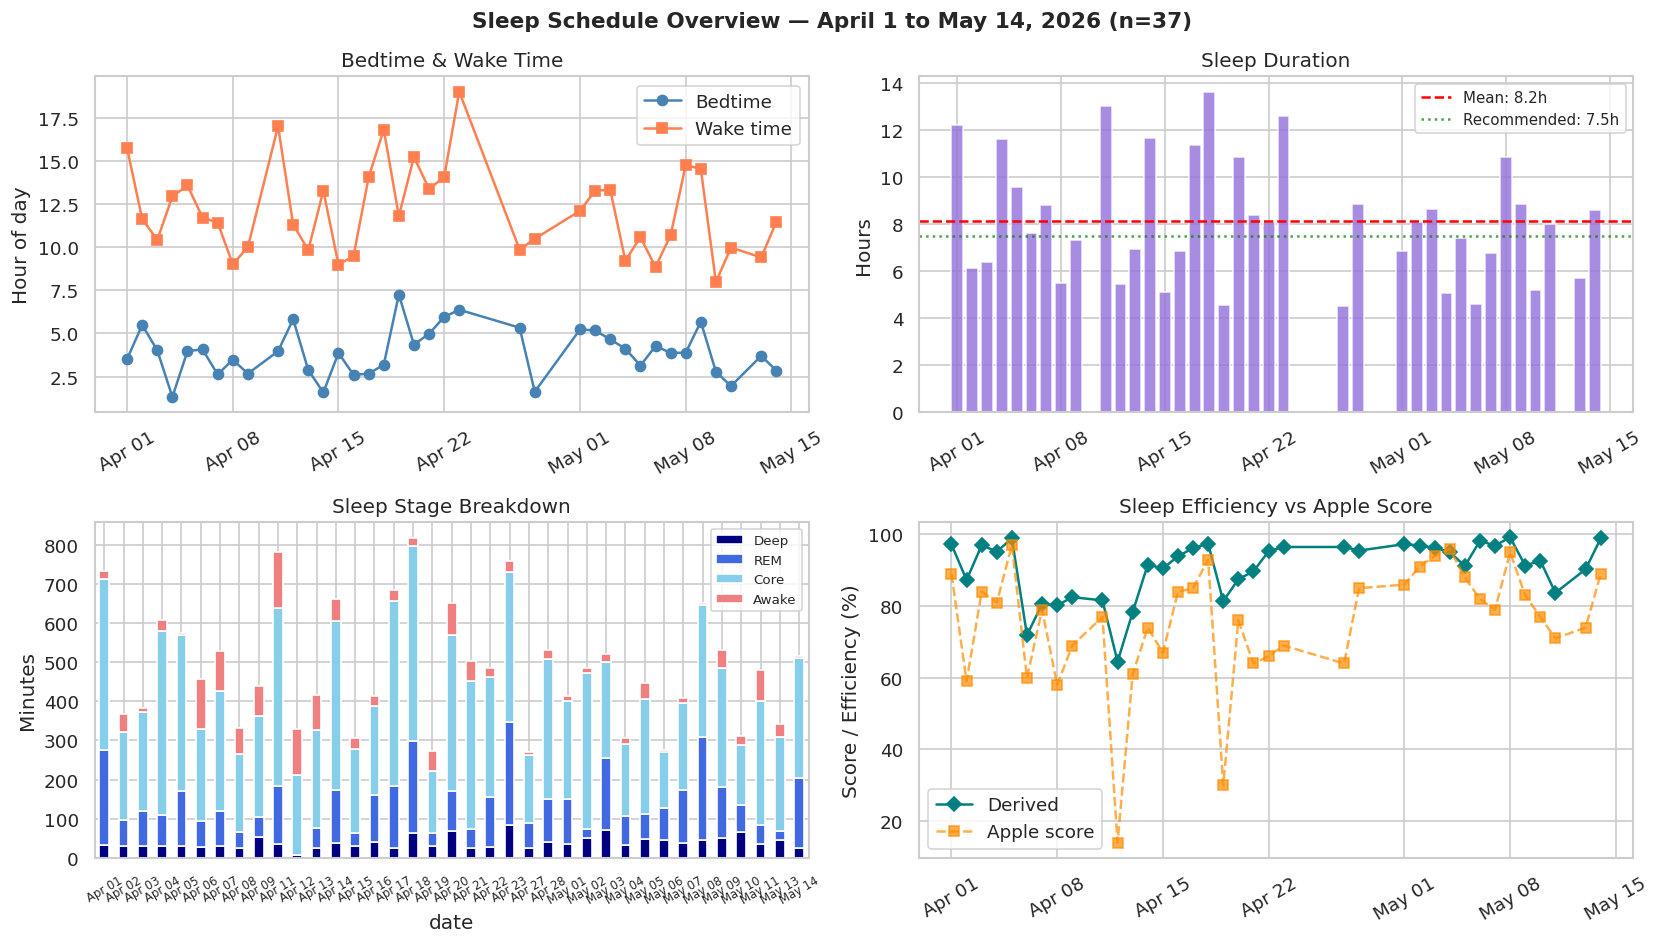

Bedtime std: 1.40h — highly irregular schedule
Duration mean: 8.2h, std: 2.6h


In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))
fig.suptitle('Sleep Schedule Overview — April 1 to May 14, 2026 (n=37)', fontsize=13, fontweight='bold')

ax = axes[0,0]
ax.plot(df_ml['date'], df_ml['bedtime_hour'], 'o-', color='steelblue', label='Bedtime')
ax.plot(df_ml['date'], df_ml['wake_hour'], 's-', color='coral', label='Wake time')
ax.set_ylabel('Hour of day'); ax.set_title('Bedtime & Wake Time')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[0,1]
ax.bar(df_ml['date'], df_ml['duration_h'], color='mediumpurple', alpha=0.8)
ax.axhline(df_ml['duration_h'].mean(), color='red', linestyle='--', label=f'Mean: {df_ml["duration_h"].mean():.1f}h')
ax.axhline(7.5, color='green', linestyle=':', alpha=0.7, label='Recommended: 7.5h')
ax.set_ylabel('Hours'); ax.set_title('Sleep Duration'); ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1,0]
stages = df_ml[['date','deep_min','rem_min','core_min','awake_min']].set_index('date')
stages.plot(kind='bar', stacked=True, ax=ax, color=['navy','royalblue','skyblue','lightcoral'])
ax.set_ylabel('Minutes'); ax.set_title('Sleep Stage Breakdown')
ax.set_xticklabels([d.strftime('%b %d') for d in df_ml['date']], rotation=30, fontsize=7)
ax.legend(['Deep','REM','Core','Awake'], fontsize=8)

ax = axes[1,1]
ax.plot(df_ml['date'], df_ml['sleep_efficiency'], 'D-', color='teal', label='Derived')
ax.plot(df_ml['date'], df_ml['apple_sleep_score'], 's--', color='darkorange', alpha=0.7, label='Apple score')
ax.set_ylabel('Score / Efficiency (%)'); ax.set_title('Sleep Efficiency vs Apple Score')
ax.legend(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('sleep_overview.png', bbox_inches='tight'); plt.show()
print(f'Bedtime std: {df_ml["bedtime_hour"].std():.2f}h — highly irregular schedule')
print(f'Duration mean: {df_ml["duration_h"].mean():.1f}h, std: {df_ml["duration_h"].std():.1f}h')

## 3. Target Variables

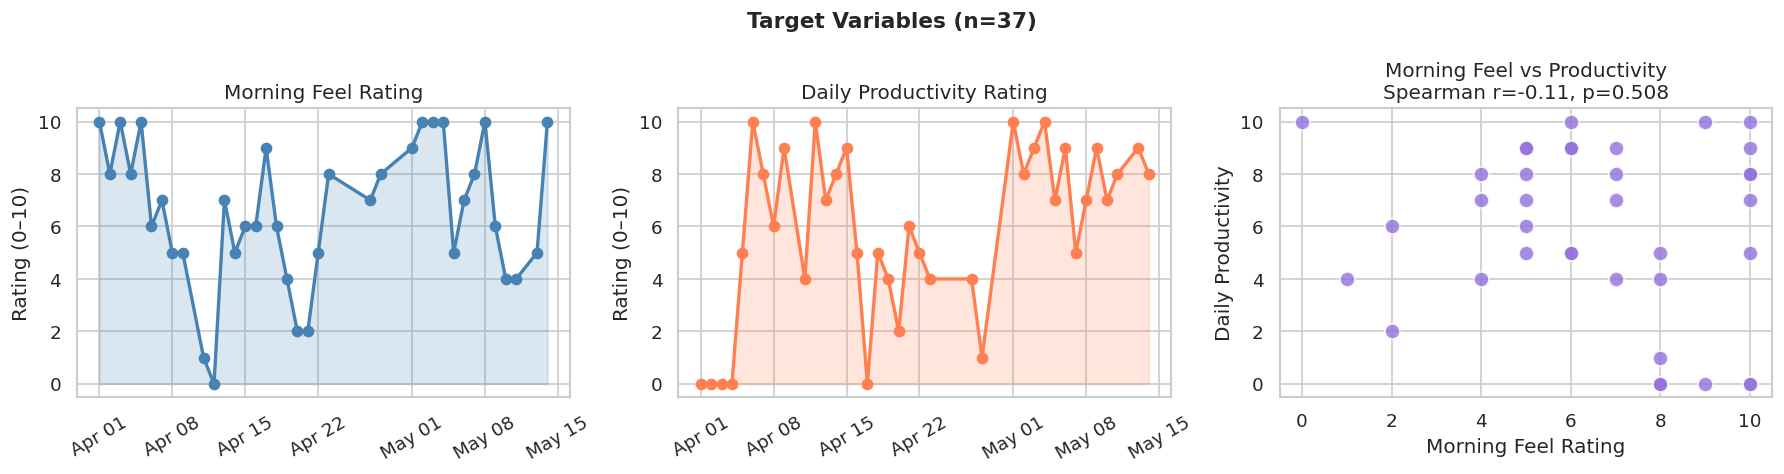

Morning Feel  — Mean: 6.6, Std: 2.7
Productivity  — Mean: 5.9, Std: 3.3
Spearman r=-0.11, p=0.508


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
fig.suptitle('Target Variables (n=37)', fontsize=13, fontweight='bold')

for ax, col, color, label in zip(axes[:2],
    ['morning_feel','productivity'], ['steelblue','coral'],
    ['Morning Feel Rating','Daily Productivity Rating']):
    ax.plot(df_ml['date'], df_ml[col], 'o-', color=color, linewidth=2)
    ax.fill_between(df_ml['date'], df_ml[col], alpha=0.2, color=color)
    ax.set_ylim(-0.5,10.5); ax.set_ylabel('Rating (0–10)'); ax.set_title(label)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[2]
ax.scatter(df_ml['morning_feel'], df_ml['productivity'], color='mediumpurple', s=80, alpha=0.8, edgecolors='white')
r, p = stats.spearmanr(df_ml['morning_feel'], df_ml['productivity'])
ax.set_xlabel('Morning Feel Rating'); ax.set_ylabel('Daily Productivity')
ax.set_title(f'Morning Feel vs Productivity\nSpearman r={r:.2f}, p={p:.3f}')

plt.tight_layout()
plt.savefig('targets.png', bbox_inches='tight'); plt.show()
print(f'Morning Feel  — Mean: {df_ml["morning_feel"].mean():.1f}, Std: {df_ml["morning_feel"].std():.1f}')
print(f'Productivity  — Mean: {df_ml["productivity"].mean():.1f}, Std: {df_ml["productivity"].std():.1f}')
print(f'Spearman r={r:.2f}, p={p:.3f}')

## 4. Lifestyle & Environmental Features

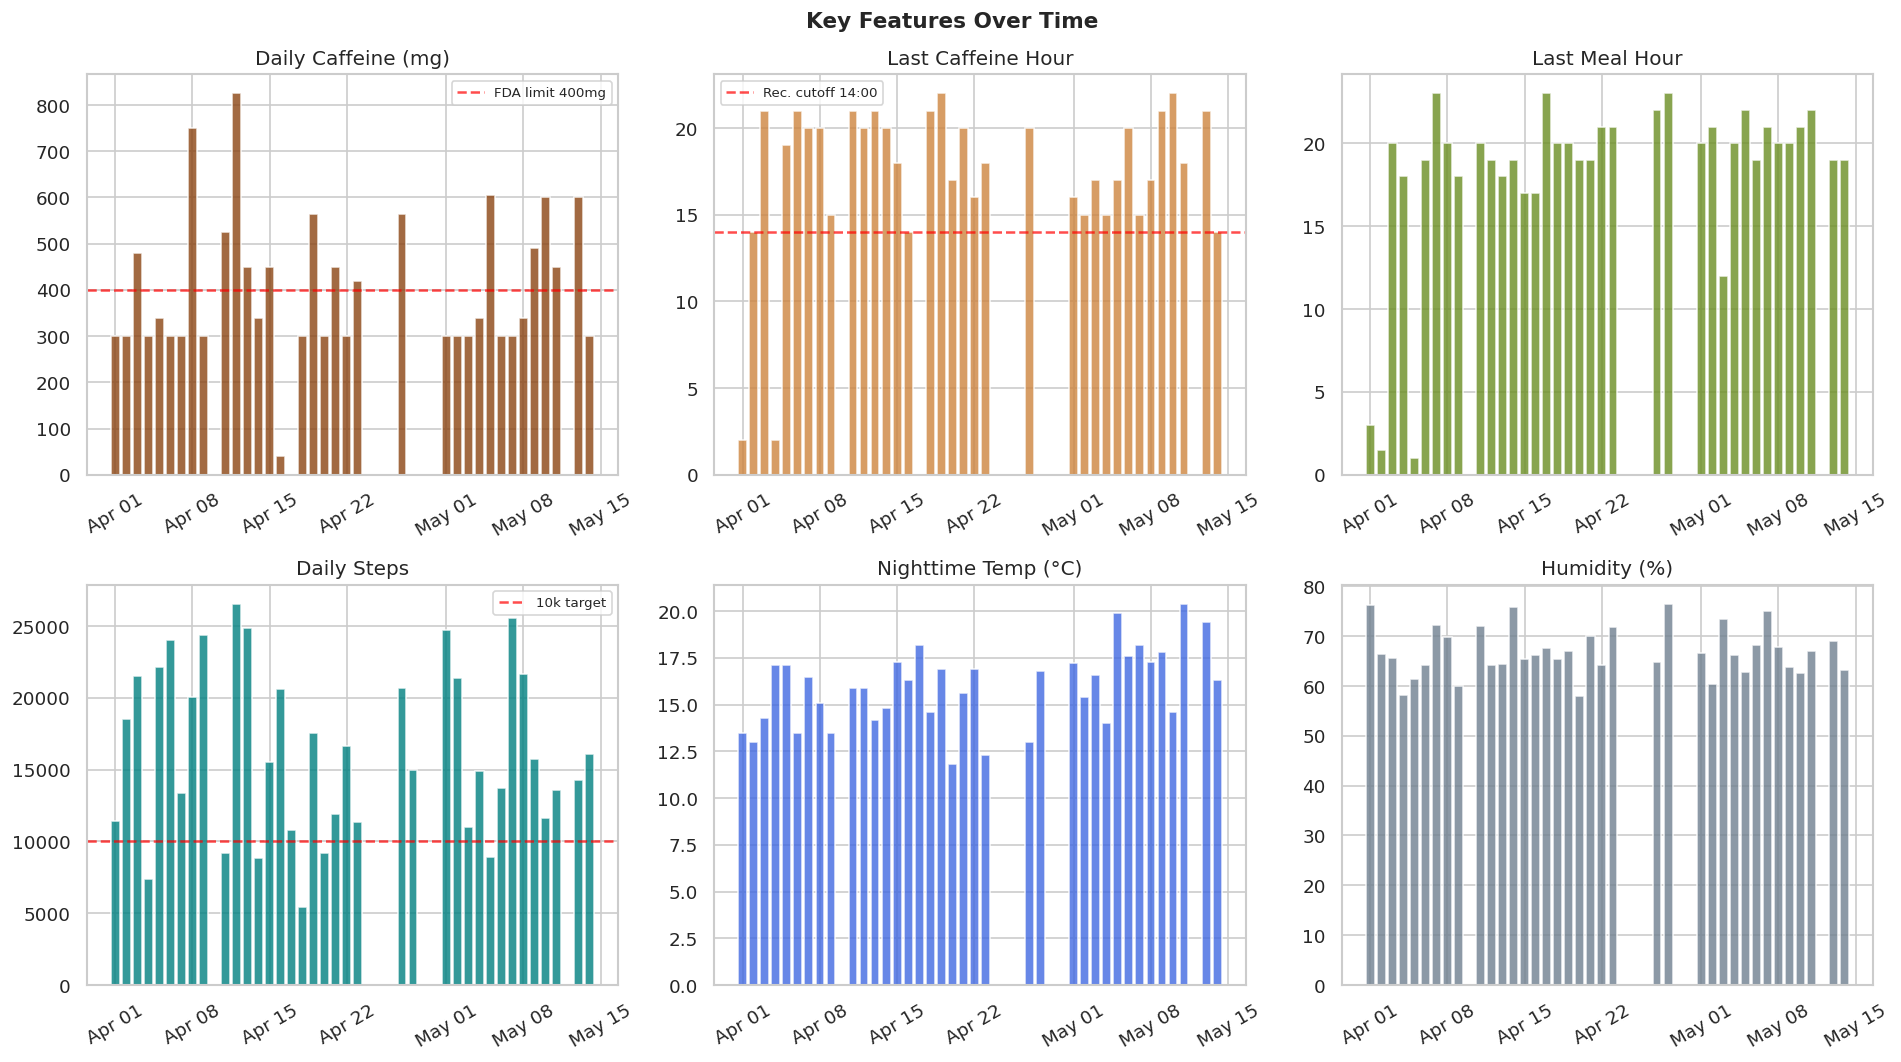

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
fig.suptitle('Key Features Over Time', fontsize=13, fontweight='bold')

plots = [
    ('caffeine_mg',       'Daily Caffeine (mg)',      'saddlebrown', 400,  'FDA limit 400mg'),
    ('last_caffeine_hour','Last Caffeine Hour',        'peru',        14,   'Rec. cutoff 14:00'),
    ('last_meal_hour',    'Last Meal Hour',            'olivedrab',   None, None),
    ('steps',             'Daily Steps',               'teal',        10000,'10k target'),
    ('temp_c',            'Nighttime Temp (°C)',       'royalblue',   None, None),
    ('humidity_pct',      'Humidity (%)',              'slategrey',   None, None),
]
for ax, (col, label, color, ref, ref_label) in zip(axes.flat, plots):
    ax.bar(df_ml['date'], df_ml[col], color=color, alpha=0.8)
    if ref: ax.axhline(ref, color='red', linestyle='--', alpha=0.7, label=ref_label); ax.legend(fontsize=8)
    ax.set_title(label); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig('features.png', bbox_inches='tight'); plt.show()

## 5. Correlation Heatmap

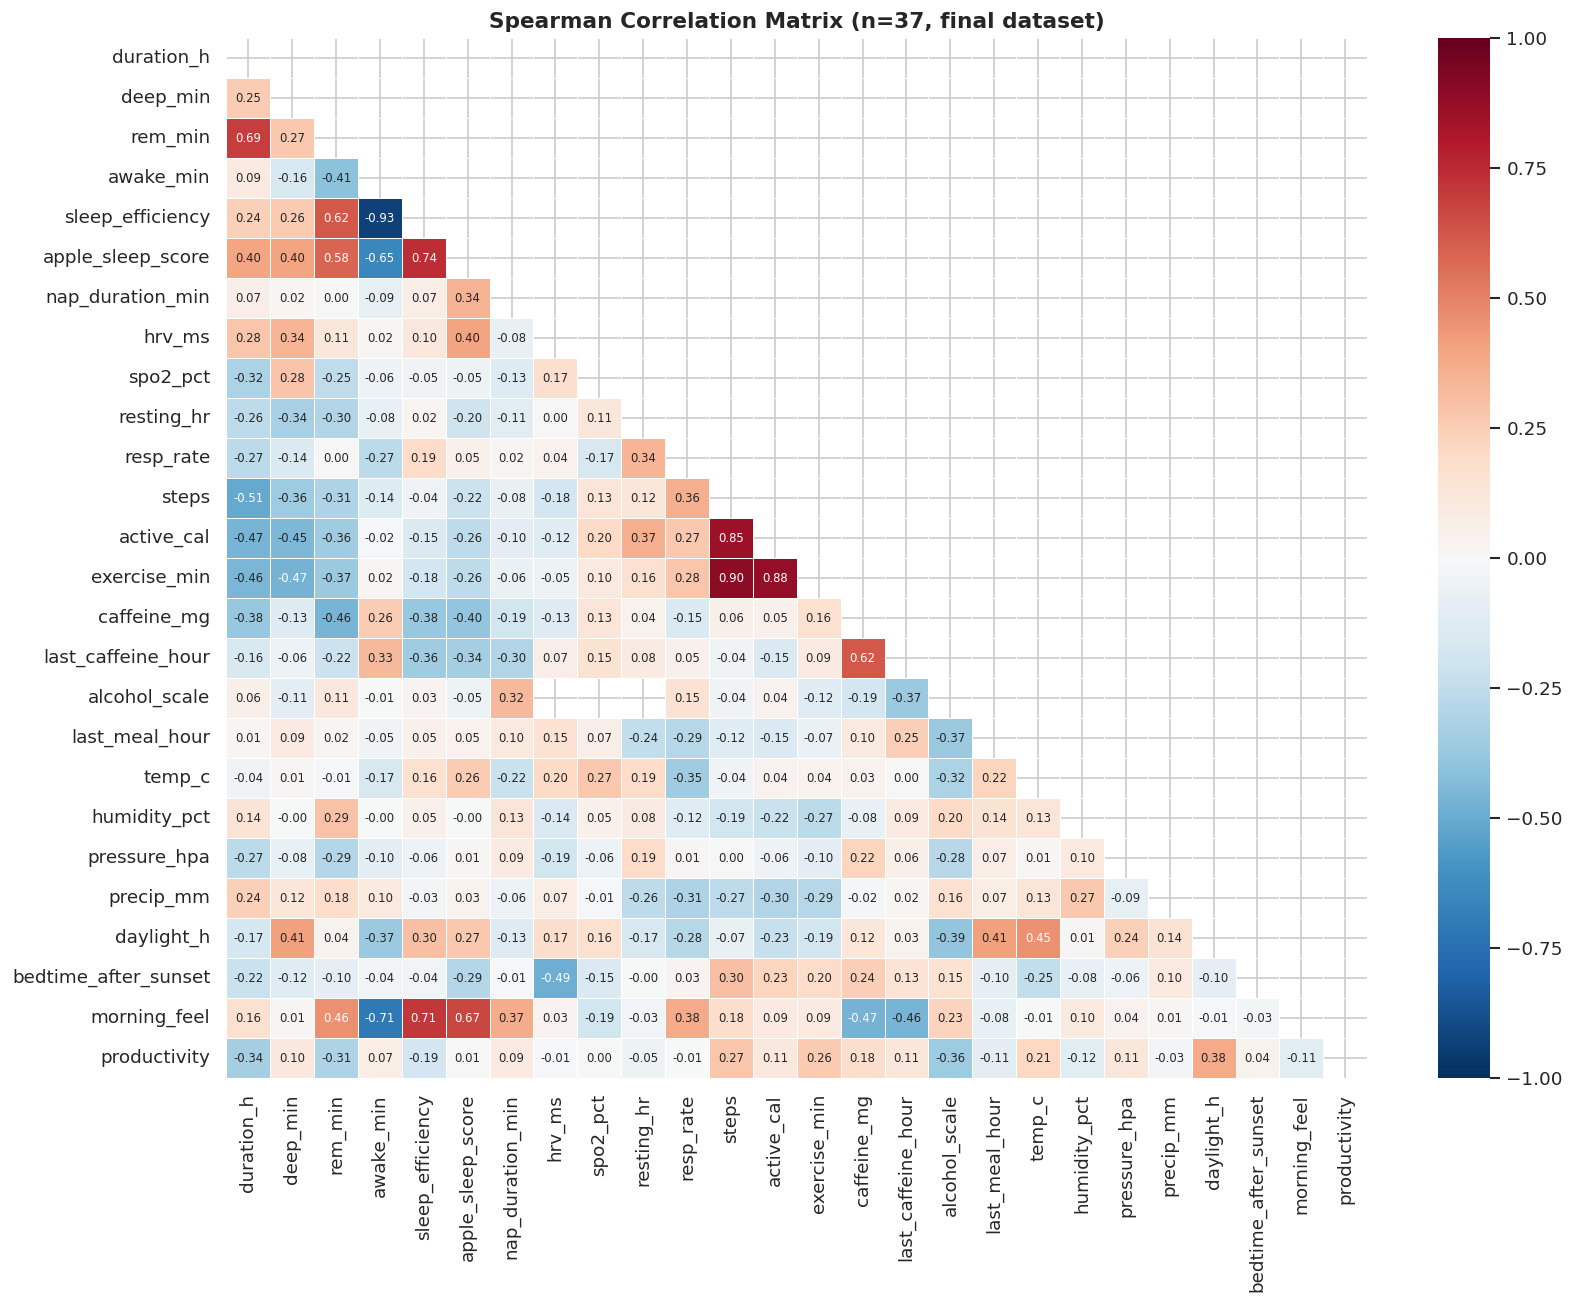

=== TOP CORRELATIONS WITH MORNING FEEL ===
awake_min            -0.712
sleep_efficiency      0.709
apple_sleep_score     0.666
caffeine_mg          -0.469
last_caffeine_hour   -0.464
rem_min               0.459
resp_rate             0.382
nap_duration_min      0.373
alcohol_scale         0.229
spo2_pct             -0.195
Name: morning_feel, dtype: float64

=== TOP CORRELATIONS WITH PRODUCTIVITY ===
daylight_h          0.382
alcohol_scale      -0.361
duration_h         -0.337
rem_min            -0.312
steps               0.274
exercise_min        0.260
temp_c              0.209
sleep_efficiency   -0.185
caffeine_mg         0.178
humidity_pct       -0.116
Name: productivity, dtype: float64


In [5]:
FEATURES = ['duration_h','deep_min','rem_min','awake_min','sleep_efficiency','apple_sleep_score',
            'nap_duration_min','hrv_ms','spo2_pct','resting_hr','resp_rate',
            'steps','active_cal','exercise_min','caffeine_mg','last_caffeine_hour',
            'alcohol_scale','last_meal_hour','temp_c','humidity_pct','pressure_hpa',
            'precip_mm','daylight_h','bedtime_after_sunset','morning_feel','productivity']

corr = df_ml[FEATURES].corr(method='spearman')
fig, ax = plt.subplots(figsize=(14,11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size':7}, linewidths=0.4)
ax.set_title('Spearman Correlation Matrix (n=37, final dataset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation.png', bbox_inches='tight'); plt.show()

print('=== TOP CORRELATIONS WITH MORNING FEEL ===')
print(corr['morning_feel'].drop('morning_feel').sort_values(key=abs, ascending=False).head(10).round(3))
print('\n=== TOP CORRELATIONS WITH PRODUCTIVITY ===')
print(corr['productivity'].drop('productivity').sort_values(key=abs, ascending=False).head(10).round(3))

## 6. Hypothesis Tests

In [6]:
print('='*65)
print('HYPOTHESIS TESTS (Spearman & Mann–Whitney U, n=37)')
print('='*65)

def sp(x_col, y_col, label):
    d = df_ml[[x_col,y_col]].dropna()
    r, p = stats.spearmanr(d[x_col], d[y_col])
    sig = '** SIGNIFICANT **' if p < 0.05 else '(not significant)'
    print(f'\nH: {label}')
    print(f'   Spearman r={r:.3f}, p={p:.3f}  {sig}')

def mw(col, target, threshold, label):
    d = df_ml[[col,target]].dropna()
    g1 = d[d[col] >= threshold][target]; g2 = d[d[col] < threshold][target]
    if len(g1)<2 or len(g2)<2: print(f'\nH: {label}\n   Insufficient groups'); return
    u, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    sig = '** SIGNIFICANT **' if p < 0.05 else '(not significant)'
    print(f'\nH: {label}')
    print(f'   Group≥{threshold} mean={g1.mean():.2f} vs <{threshold} mean={g2.mean():.2f}')
    print(f'   Mann–Whitney U={u:.0f}, p={p:.3f}  {sig}')

sp('duration_h',           'morning_feel',     'Longer sleep → higher morning feel')
sp('rem_min',              'morning_feel',     'More REM → higher morning feel')
sp('awake_min',            'morning_feel',     'More awake time → lower morning feel')
sp('sleep_efficiency',     'morning_feel',     'Higher sleep efficiency → better morning feel')
sp('apple_sleep_score',    'morning_feel',     'Higher Apple score → better morning feel')
sp('caffeine_mg',          'sleep_efficiency', 'Higher caffeine → lower sleep efficiency')
sp('last_caffeine_hour',   'awake_min',        'Later caffeine → more awake time')
sp('bedtime_after_sunset', 'morning_feel',     'Later bedtime after sunset → worse morning feel')
sp('temp_c',               'sleep_efficiency', 'Higher temperature → lower sleep efficiency')
sp('morning_feel',         'productivity',     'Higher morning feel → higher productivity')
sp('steps',                'productivity',     'More daily steps → higher productivity')
mw('caffeine_mg',          'morning_feel', 400,'Caffeine ≥400mg vs <400mg: morning feel difference')
mw('alcohol_scale',        'morning_feel', 1,  'Any alcohol vs none: morning feel difference')

print('\n'+'='*65)
print('NOTE: n=37; interpret p-values cautiously. Results are exploratory.')
print('='*65)

HYPOTHESIS TESTS (Spearman & Mann–Whitney U, n=37)

H: Longer sleep → higher morning feel
   Spearman r=0.157, p=0.355  (not significant)

H: More REM → higher morning feel
   Spearman r=0.459, p=0.004  ** SIGNIFICANT **

H: More awake time → lower morning feel
   Spearman r=-0.712, p=0.000  ** SIGNIFICANT **

H: Higher sleep efficiency → better morning feel
   Spearman r=0.709, p=0.000  ** SIGNIFICANT **

H: Higher Apple score → better morning feel
   Spearman r=0.666, p=0.000  ** SIGNIFICANT **

H: Higher caffeine → lower sleep efficiency
   Spearman r=-0.377, p=0.022  ** SIGNIFICANT **

H: Later caffeine → more awake time
   Spearman r=0.328, p=0.055  (not significant)

H: Later bedtime after sunset → worse morning feel
   Spearman r=-0.030, p=0.859  (not significant)

H: Higher temperature → lower sleep efficiency
   Spearman r=0.160, p=0.344  (not significant)

H: Higher morning feel → higher productivity
   Spearman r=-0.112, p=0.508  (not significant)

H: More daily steps → high

## 7. Weather & Circadian Rhythm Analysis

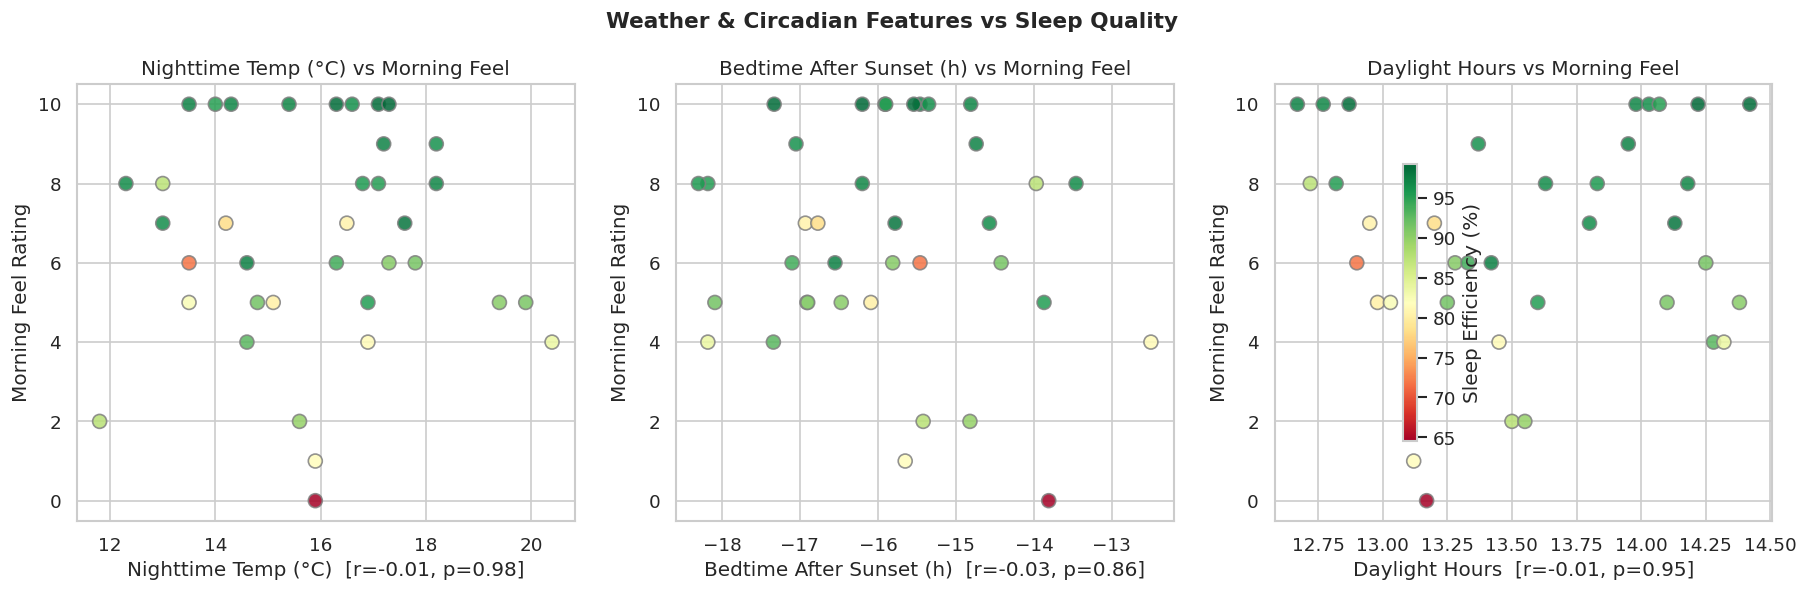

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
fig.suptitle('Weather & Circadian Features vs Sleep Quality', fontsize=13, fontweight='bold')

for ax, x_col, label in zip(axes,
    ['temp_c','bedtime_after_sunset','daylight_h'],
    ['Nighttime Temp (°C)','Bedtime After Sunset (h)','Daylight Hours']):
    r, p = stats.spearmanr(df_ml[x_col], df_ml['morning_feel'])
    ax.scatter(df_ml[x_col], df_ml['morning_feel'], c=df_ml['sleep_efficiency'],
               cmap='RdYlGn', s=70, edgecolors='grey', alpha=0.85)
    ax.set_xlabel(f'{label}  [r={r:.2f}, p={p:.2f}]')
    ax.set_ylabel('Morning Feel Rating'); ax.set_title(f'{label} vs Morning Feel')

fig.colorbar(plt.cm.ScalarMappable(cmap='RdYlGn',
    norm=plt.Normalize(df_ml['sleep_efficiency'].min(), df_ml['sleep_efficiency'].max())),
    ax=axes, label='Sleep Efficiency (%)', shrink=0.6)
plt.tight_layout()
plt.savefig('weather_circadian.png', bbox_inches='tight'); plt.show()